# Good Year / Bad Year — Probabilistic Habitat Forecasts

This ports `03-ProbabilisticModel (XG_RF).r`: turn a deterministic point
prediction into a probabilistic forecast of habitat *category*, and score how
good that forecast is.

**Method, per lake:**
1. Take the best deterministic model's LOOCV predictions from
   [`02_deterministic_models.ipynb`](02_deterministic_models.ipynb) (highest
   LOOCV R²).
2. Fit a normal distribution to that model's residuals (observed − predicted).
3. For each lake-year, draw a 100-member ensemble: predicted value + a random
   draw from that residual distribution (negative habitat is clipped to 0).
4. Define **tercile categories** from the observed CVHT distribution —
   **Below Normal** (bottom third, a *bad* coldwater-habitat year), **Near
   Normal**, **Above Normal** (top third, a *good* year) — and score what
   fraction of the ensemble falls in each category. The category with the
   most ensemble members is the forecast.
5. Score the forecasts against a naive 1/3-1/3-1/3 climatology baseline with
   the **Heidke Skill Score (HSS)** and **Ranked Probability Skill Score
   (RPSS)**: 0 means "no better than climatology," 1 means "perfect."

With ~40 years per lake this is a small-sample, illustrative skill
evaluation — not a claim of forecast-grade accuracy — but it reproduces the
same categorical-forecast framing used in seasonal climate outlooks.


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from src.data import LAKE_NAMES
from src.probabilistic import forecast_table, skill_scores, confusion_matrix, CATEGORIES
from src.viz import set_style, LAKE_COLORS, CATEGORY_COLORS, YEAR_TYPE_COLORS

set_style()
pio.renderers.default = "png"

export_all = pd.read_csv("../outputs/cvht_obs_preds_all_models_python.csv")
scores = pd.read_csv("../outputs/cvht_model_scores_python.csv")

best_model_col = {"PCR": "pred_pcr", "Random Forest": "pred_rf", "XGBoost": "pred_xgb"}
best_per_lake = scores.loc[scores.groupby("lake_id")["r_squared"].idxmax()].set_index("lake_id")["model"]
best_per_lake


lake_id
AL    Random Forest
BM              PCR
CR    Random Forest
SP              PCR
TR              PCR
Name: model, dtype: str

In [2]:
forecasts = {}
for lake_id, model_name in best_per_lake.items():
    g = export_all[export_all["lake_id"] == lake_id].sort_values("year").reset_index(drop=True)
    pred_col = best_model_col[model_name]
    table = forecast_table(g["year"].to_numpy(), g["observed_cvht"].to_numpy(), g[pred_col].to_numpy())
    table.insert(0, "lake_id", lake_id)
    forecasts[lake_id] = table

all_forecasts = pd.concat(forecasts.values(), ignore_index=True)
all_forecasts.to_csv("../outputs/good_bad_year_forecasts_python.csv", index=False)
all_forecasts.head()


,lake_id,year,observed_cvht,predicted_cvht,prob_below_normal,prob_near_normal,prob_above_normal,predicted_category,observed_category,predicted_year_type,observed_year_type
0,AL,1981,0.0,4.815155,0.21,0.19,0.60,Above Normal,Below Normal,Good year,Bad year
1,AL,1982,6.0,2.772975,0.49,0.17,0.34,Below Normal,Above Normal,Bad year,Good year
2,AL,1983,3.5,4.690297,0.27,0.13,0.60,Above Normal,Near Normal,Good year,Normal year
3,AL,1984,3.5,6.392641,0.14,0.07,0.79,Above Normal,Near Normal,Good year,Normal year
4,AL,1985,7.5,5.852820,0.17,0.11,0.72,Above Normal,Above Normal,Good year,Good year


## Skill scores by lake

HSS and RPSS versus a naive climatology baseline (0 = no skill, 1 = perfect).

In [3]:
skill_rows = []
for lake_id, table in forecasts.items():
    s = skill_scores(table)
    s["lake_id"] = lake_id
    s["model"] = best_per_lake[lake_id]
    skill_rows.append(s)
skill_df = pd.DataFrame(skill_rows)[["lake_id", "model", "hss", "rpss", "n_years"]]
skill_df.to_csv("../outputs/skill_scores_python.csv", index=False)
skill_df.round(3)


,lake_id,model,hss,rpss,n_years
0,AL,Random Forest,-0.057,0.115,44
1,BM,PCR,0.250,0.535,44
2,CR,Random Forest,0.080,0.070,44
3,SP,PCR,0.114,0.348,44
4,TR,PCR,-0.023,0.371,44


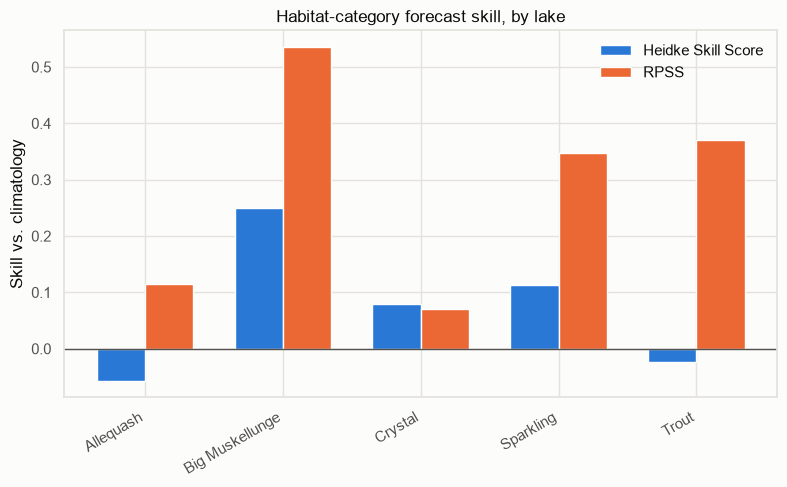

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(skill_df))
width = 0.35
ax.bar(x - width / 2, skill_df["hss"], width, label="Heidke Skill Score", color="#2a78d6")
ax.bar(x + width / 2, skill_df["rpss"], width, label="RPSS", color="#eb6834")
ax.axhline(0, color="#52514e", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([LAKE_NAMES[l] for l in skill_df["lake_id"]], rotation=30, ha="right")
ax.set_ylabel("Skill vs. climatology")
ax.set_title("Habitat-category forecast skill, by lake")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("../figures/03_skill_scores.png", dpi=150)
plt.show()


## Lake habitat classification heatmap

Each cell is one lake-year, colored by the **forecast** habitat category (diverging: red = Bad year / Below Normal, gray = Normal, blue = Good year / Above Normal). This is the Python counterpart to `09_Lake Classification Heatmap.R`.

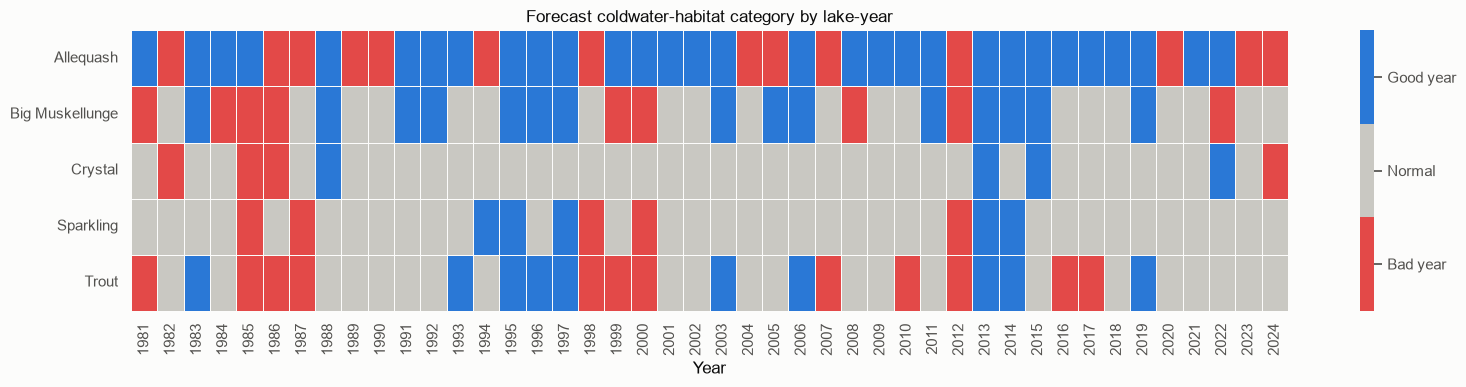

In [5]:
cat_order = CATEGORIES  # Below Normal, Near Normal, Above Normal
cat_to_num = {c: i for i, c in enumerate(cat_order)}
heat = all_forecasts.copy()
heat["lake_name"] = heat["lake_id"].map(LAKE_NAMES)
heat["cat_num"] = heat["predicted_category"].map(cat_to_num)
pivot = heat.pivot(index="lake_name", columns="year", values="cat_num")

cmap = mcolors.ListedColormap([CATEGORY_COLORS[c] for c in cat_order])
fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    pivot, cmap=cmap, vmin=-0.5, vmax=2.5, cbar_kws={"ticks": [0, 1, 2]}, linewidths=0.5,
    linecolor="#fcfcfb", ax=ax,
)
cbar = ax.collections[0].colorbar
cbar.set_ticklabels(["Bad year", "Normal", "Good year"])
ax.set_xlabel("Year")
ax.set_ylabel("")
ax.set_title("Forecast coldwater-habitat category by lake-year")
fig.tight_layout()
fig.savefig("../figures/03_classification_heatmap.png", dpi=150)
plt.show()


Interactive version — hover a cell for the exact category probabilities.

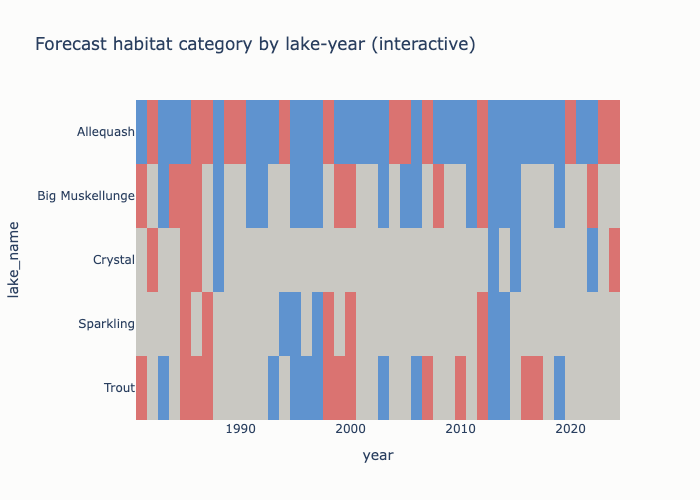

In [6]:
heat["hover"] = (
    "Below Normal: " + (heat["prob_below_normal"] * 100).round(0).astype(int).astype(str) + "%<br>"
    + "Near Normal: " + (heat["prob_near_normal"] * 100).round(0).astype(int).astype(str) + "%<br>"
    + "Above Normal: " + (heat["prob_above_normal"] * 100).round(0).astype(int).astype(str) + "%"
)
hover_pivot = heat.pivot(index="lake_name", columns="year", values="hover")

fig = px.imshow(
    pivot, color_continuous_scale=[CATEGORY_COLORS[c] for c in cat_order],
    range_color=(-0.5, 2.5), aspect="auto",
    title="Forecast habitat category by lake-year (interactive)", labels={"color": "Category"},
)
fig.data[0].customdata = hover_pivot.values
fig.data[0].hovertemplate = "%{y}, %{x}<br>%{customdata}<extra></extra>"
fig.update_coloraxes(showscale=False)
fig.update_layout(plot_bgcolor="#fcfcfb", paper_bgcolor="#fcfcfb")
fig.show()


## Confusion matrix: forecast vs. observed category (all lakes combined)

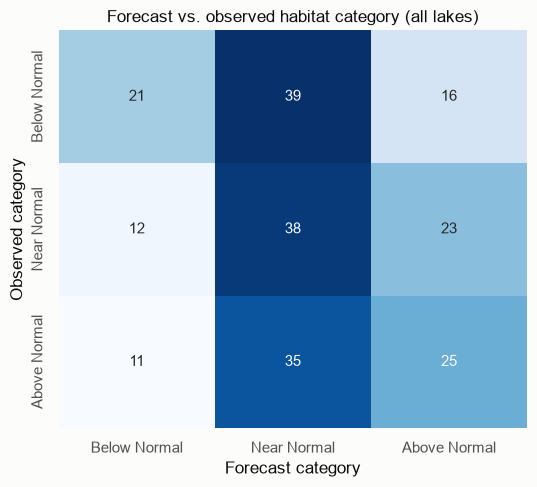

In [7]:
combined_confusion = sum(
    (confusion_matrix(t) for t in forecasts.values()),
    pd.DataFrame(0, index=CATEGORIES, columns=CATEGORIES),
)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(combined_confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("Forecast category")
ax.set_ylabel("Observed category")
ax.set_title("Forecast vs. observed habitat category (all lakes)")
fig.tight_layout()
fig.savefig("../figures/03_confusion_matrix.png", dpi=150)
plt.show()
